# 🏏 IPL Exploratory Data Analysis

### Objective:
To analyze IPL matches and player performance using Pandas, NumPy, Matplotlib and Seaborn.

### Dataset:
matches.csv and deliveries.csv

#1. Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10,5)

#2. Load Dataset

In [35]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

#3. Show First Rows

In [36]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [37]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,4.0,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,2.0,NaN,NaN,NaN


#4. Dataset Overview

In [38]:
matches.shape

(756, 18)

In [39]:
deliveries.shape

(71611, 21)

In [40]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [41]:
deliveries.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71611 entries, 0 to 71610
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          71611 non-null  int64  
 1   inning            71611 non-null  int64  
 2   batting_team      71611 non-null  object 
 3   bowling_team      71611 non-null  object 
 4   over              71611 non-null  int64  
 5   ball              71611 non-null  int64  
 6   batsman           71611 non-null  object 
 7   non_striker       71610 non-null  object 
 8   bowler            71610 non-null  object 
 9   is_super_over     71610 non-null  float64
 10  wide_runs         71610 non-null  float64
 11  bye_runs          71610 non-null  float64
 12  legbye_runs       71610 non-null  float64
 13  noball_runs       71610 non-null  float64
 14  penalty_runs      71610 non-null  float64
 15  batsman_runs      71610 non-null  float64
 16  extra_runs        71610 non-null  float6

In [42]:
matches.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,2013.444444,0.025132,13.283069,3.350529
std,3464.478148,3.366895,0.156630,23.471144,3.387963
min,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,189.750000,2011.000000,0.000000,0.000000,0.000000
50%,378.500000,2013.000000,0.000000,0.000000,4.000000
75%,567.250000,2016.000000,0.000000,19.000000,6.000000
max,11415.000000,2019.000000,1.000000,146.000000,10.000000


In [43]:
deliveries.describe()

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
count,71611.000000,71611.000000,71611.000000,71611.000000,71610.000000,71610.000000,71610.000000,71610.000000,71610.000000,71610.000000,71610.000000,71610.000000,71610.000000
mean,152.227423,1.479270,10.095404,3.624010,0.000461,0.039897,0.005656,0.023083,0.004985,0.000070,1.210543,0.073691,1.284234
std,87.168841,0.501387,5.665224,1.813738,0.021462,0.267890,0.121016,0.204573,0.079027,0.018685,1.590096,0.362775,1.579098
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,77.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,153.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,227.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,304.000000,4.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,5.000000,5.000000,6.000000,5.000000,7.000000


In [44]:
matches.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [45]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [46]:
matches.dtypes

,0
id,int64
season,int64
city,object
date,object
team1,object
team2,object
toss_winner,object
toss_decision,object
result,object
dl_applied,int64


In [47]:
deliveries.dtypes

,0
match_id,int64
inning,int64
batting_team,object
bowling_team,object
over,int64
ball,int64
batsman,object
non_striker,object
bowler,object
is_super_over,float64


#5.  Missing Values

In [48]:
matches.isnull().sum()

,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [49]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0
non_striker,1
bowler,1
is_super_over,1


#6.  Duplicate Values

In [50]:
matches.duplicated().sum()

np.int64(0)

In [51]:
deliveries.duplicated().sum()

np.int64(1)

#7. Top Winning Teams

In [52]:
matches['winner'].value_counts().head(10)

,count
winner,
Mumbai Indians,109
Chennai Super Kings,100
Kolkata Knight Riders,92
Royal Challengers Bangalore,84
Kings XI Punjab,82
Rajasthan Royals,75
Delhi Daredevils,67
Sunrisers Hyderabad,58
Deccan Chargers,29


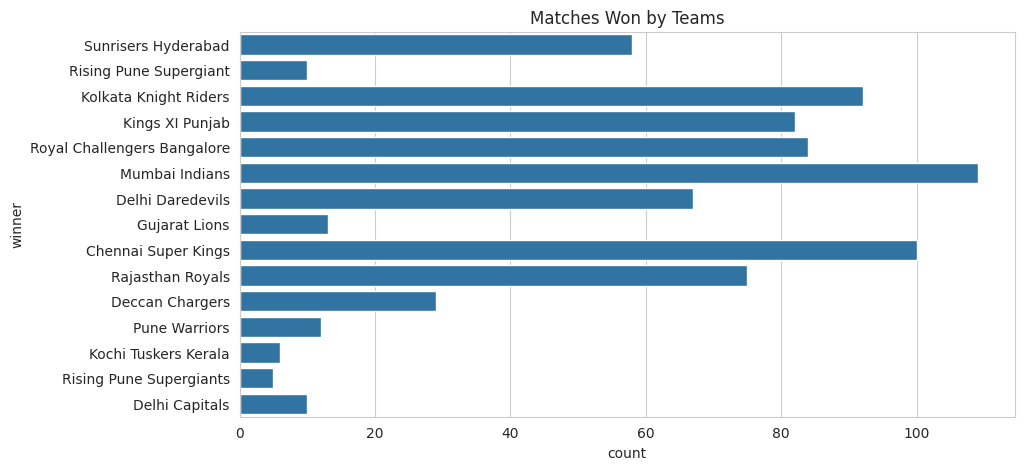

In [53]:
sns.countplot(y='winner', data=matches)
plt.title("Matches Won by Teams")
plt.show()

#8. Toss Winner Analysis

In [54]:
matches['toss_winner'].value_counts().head()

,count
toss_winner,
Mumbai Indians,98
Kolkata Knight Riders,92
Chennai Super Kings,89
Kings XI Punjab,81
Royal Challengers Bangalore,81


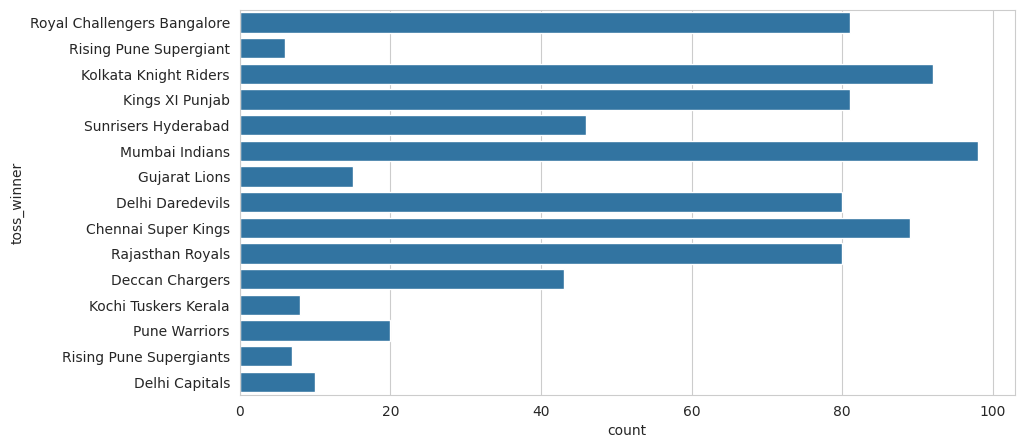

In [55]:
sns.countplot(y='toss_winner', data=matches)
plt.show()

#9. Matches Per Season

In [56]:
matches['season'].value_counts()

,count
season,
2013,76
2012,74
2011,73
2010,60
2016,60
2018,60
2019,60
2014,60
2017,59


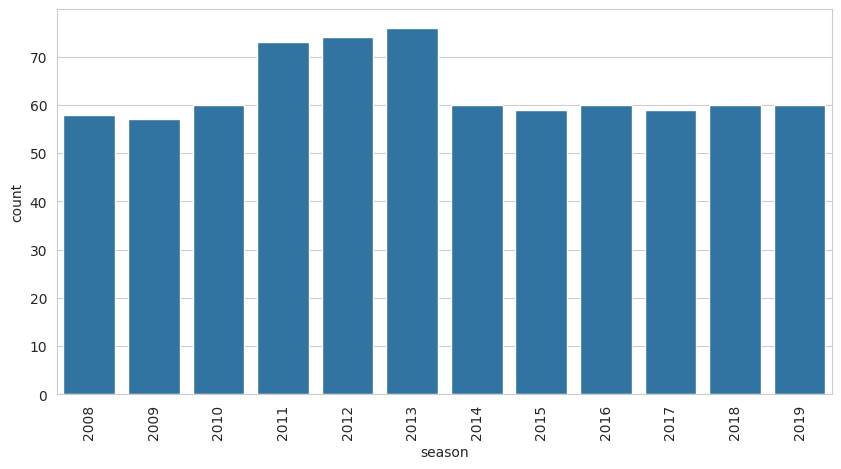

In [57]:
sns.countplot(x='season', data=matches)
plt.xticks(rotation=90)
plt.show()

#10. Top Run Scorers

In [58]:
top_batsman = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

top_batsman

,batsman_runs
batsman,
SK Raina,2182.0
G Gambhir,1969.0
RG Sharma,1862.0
MS Dhoni,1664.0
SR Tendulkar,1647.0
AC Gilchrist,1603.0
JH Kallis,1549.0
V Kohli,1540.0
SE Marsh,1531.0


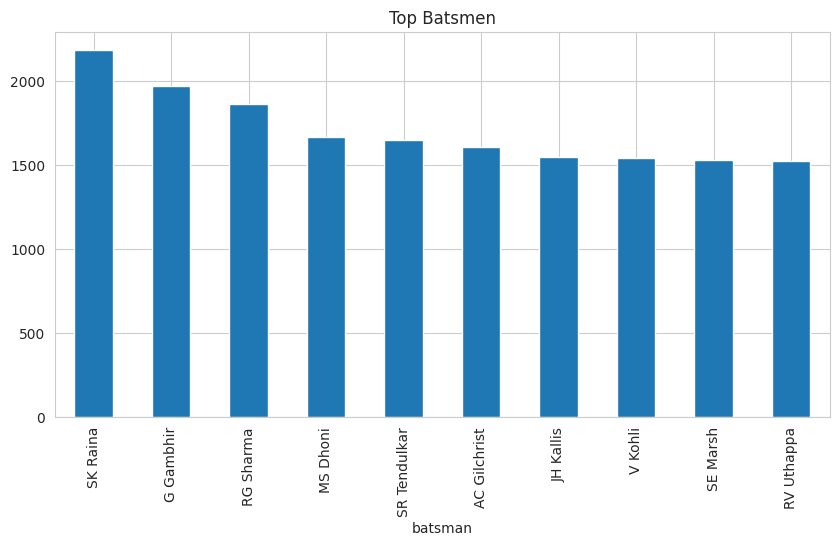

In [59]:
top_batsman.plot(kind='bar')
plt.title("Top Batsmen")
plt.show()

#11. Players with Most Sixes

In [60]:
deliveries[deliveries['batsman_runs']==6]['batsman'].value_counts().head(10)

,count
batsman,
SK Raina,85
YK Pathan,82
AC Gilchrist,82
CH Gayle,79
Yuvraj Singh,75
RG Sharma,73
RV Uthappa,70
MS Dhoni,68
BB McCullum,63


#12. Correlation Heatmap

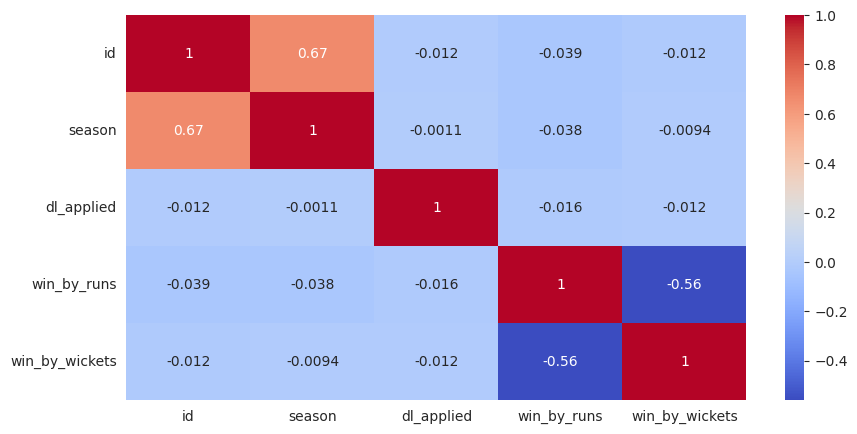

In [61]:
sns.heatmap(matches.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

#1️3. Outlier Detection

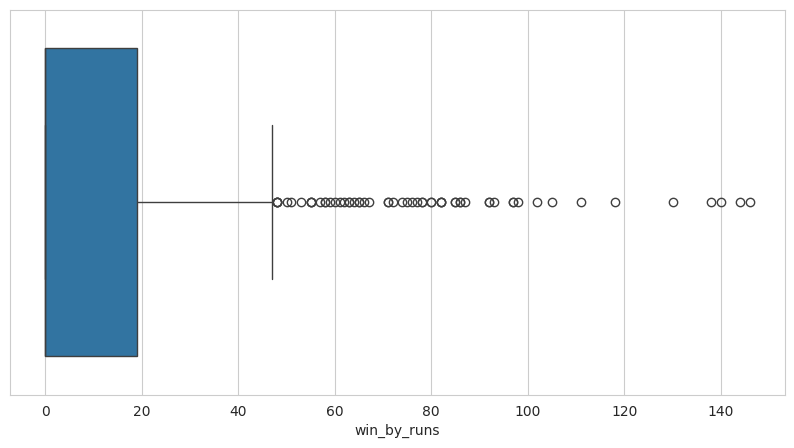

In [62]:
sns.boxplot(x=matches['win_by_runs'])
plt.show()

#1️4. Feature Engineering

In [63]:
matches['Total_Margin'] = matches['win_by_runs'] + matches['win_by_wickets']

In [64]:
matches[['win_by_runs','win_by_wickets','Total_Margin']].head()

,win_by_runs,win_by_wickets,Total_Margin
0,35,0,35
1,0,7,7
2,0,10,10
3,0,6,6
4,15,0,15


#1️5. Business Insights


1. Mumbai Indians won the maximum matches.
2. Toss affects match results.
3. Some teams dominate particular seasons.
4. Top batsmen contribute heavily to wins.
5. Six hitters impact the match significantly.
6. Winning margins vary across teams.
7. Team performance changes season-wise.
8. IPL data helps understand strategies.

#16. Conclusion

This IPL EDA project analyzed team performance, player statistics, toss impact, and winning trends using Pandas, NumPy, Matplotlib, and Seaborn.